# Plan - Bloc 2
1. Inventaire des colonnes → classer chacune (target, leakage, inutile, exploitable, transformable)
2. Supprimer les colonnes leakage et inutiles
3. Regrouper les colonnes restantes par catégorie métier
4. Pour chaque catégorie :
- Lister les colonnes brutes disponibles
- Identifier l'information implicite exploitable
- Créer les features
- Test leakage sur chaque feature créée
- Documenter chaque feature : pourquoi elle existe, ce qu'elle capture métier
  
10. Vérifier les distributions des nouvelles features (outliers, valeurs aberrantes introduites)
11. Vérifier la corrélation entre nouvelles features (éviter la redondance)
12. Gérer les NaN introduits par les calculs
13. Supprimer les colonnes brutes remplacées
14. Bilan : shape avant/après, .describe(), liste des nouvelles colonnes

In [56]:
import pandas as pd
import matplotlib.pyplot as plt 
import missingno as msno
import seaborn as sns
from scipy.stats import spearmanr

In [57]:
df = pd.read_csv('../data/2016_Building_Energy_Benchmarking.csv')

In [58]:
# Step 1 : Isolation du df des bâtiments à fonction residentielle
# On selectionne de nouveaux uniquement les type non residentiels et on l'instancie.abs
df['BuildingType'].value_counts()
# Les colonnes non residentiel sont :['NonResidential', 'Nonresidential COS', 'SPS-District K-12', 'Nonresidential WA', 'Campus']
df_s1 = df[df['BuildingType'].isin(['NonResidential', 'Nonresidential COS', 'SPS-District K-12', 'Nonresidential WA', 'Campus'])]

print(f"Avant {len(df)} lignes, après {len(df_s1)}")

Avant 3376 lignes, après 1668


In [59]:
# Step 2 : Préselection des colonnes du df pour le featuring
# Les colonnes à garder pour la modelisation, selon l'EDA.
feats_to_keep = [
    'BuildingType',
    'PrimaryPropertyType',
    'Neighborhood',
    'NumberofBuildings',
    'NumberofFloors',
    'PropertyGFATotal',
    'PropertyGFAParking',
    'PropertyGFABuilding(s)',
    'ListOfAllPropertyUseTypes',
    'LargestPropertyUseType',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType',
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType',
    'ThirdLargestPropertyUseTypeGFA',
    'SiteEnergyUse(kBtu)',
]
# Les features qui vont servir uniquement à la creation de nouvelles features mais qui seront suprimer ensuite.
feats_for_eng = [
    'YearBuilt',
    'Electricity(kWh)',
    'NaturalGas(therms)',
    'SteamUse(kBtu)',
]

# Features uniquement pour la creation des features elles seront supprimer par la suite
df_s2 = df_s1[feats_to_keep + feats_for_eng]

# On regarde que le nombre de lignes correspond et que tout est là
print(df_s2.info())



<class 'pandas.DataFrame'>
Index: 1668 entries, 0 to 3375
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   BuildingType                     1668 non-null   str    
 1   PrimaryPropertyType              1668 non-null   str    
 2   Neighborhood                     1668 non-null   str    
 3   NumberofBuildings                1666 non-null   float64
 4   NumberofFloors                   1668 non-null   int64  
 5   PropertyGFATotal                 1668 non-null   int64  
 6   PropertyGFAParking               1668 non-null   int64  
 7   PropertyGFABuilding(s)           1668 non-null   int64  
 8   ListOfAllPropertyUseTypes        1666 non-null   str    
 9   LargestPropertyUseType           1662 non-null   str    
 10  LargestPropertyUseTypeGFA        1662 non-null   float64
 11  SecondLargestPropertyUseType     855 non-null    str    
 12  SecondLargestPropertyUseTypeGFA  855

Création des features : 
Âge des bâtiments; Donne l'age du batiment plus pertinent que l'année de construction pour le modele : 
building_age = (2016) – yearbuilt

- ratio_parking : partie/total
- ratio_build : partie/total
- use_electricity : notna().astypes()
- use_gas : notna().astypes()
- use_steam : notna().astypes()
- sum_energy_use : sum()
- ratio_prime_gfa : partie/total
- ratio_second_gfa : partie/total
- ratio_third_gfa : partie/total



In [60]:
df_s2.columns.tolist()

['BuildingType',
 'PrimaryPropertyType',
 'Neighborhood',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'SiteEnergyUse(kBtu)',
 'YearBuilt',
 'Electricity(kWh)',
 'NaturalGas(therms)',
 'SteamUse(kBtu)']

In [61]:
# Step 3: Featuring
# feature âge des bâtiments
df_s2['building_age'] = 2016 - df_s2['YearBuilt']

# feature du groupe des surfaces des structures
df_s2['ratio_parking'] =  df_s2['PropertyGFAParking'] / df_s2['PropertyGFATotal']
df_s2['ratio_build'] =  df_s2['PropertyGFABuilding(s)'] / df_s2['PropertyGFATotal']

# features pour le type d'energie utilisée
df_s2['use_electricity'] = (df_s2['Electricity(kWh)'] > 0).astype(int)
df_s2['use_gaz'] = (df_s2['NaturalGas(therms)'] > 0).astype(int)
df_s2['use_steam'] = (df_s2['SteamUse(kBtu)'] > 0).astype(int)
df_s2['sum_energy_use'] = df_s2['use_electricity'] + df_s2['use_gaz'] + df_s2['use_steam']

# feature pour les ratios de surface des usages
df_s2['total_ty_gfa'] = (df_s2['LargestPropertyUseTypeGFA'] + df_s2['SecondLargestPropertyUseTypeGFA'].fillna(0) + df_s2['ThirdLargestPropertyUseTypeGFA'].fillna(0))
df_s2['ratio_prime_ty_gfa'] =  df_s2['LargestPropertyUseTypeGFA'] / df_s2['total_ty_gfa']
df_s2['ratio_second_ty_gfa'] =  df_s2['SecondLargestPropertyUseTypeGFA'].fillna(0) / df_s2['total_ty_gfa']
df_s2['ratio_third_ty_gfa'] =  df_s2['ThirdLargestPropertyUseTypeGFA'].fillna(0) / df_s2['total_ty_gfa']

# feature pour quantifier les usages
df_s2['has_second_use'] = df_s2['SecondLargestPropertyUseTypeGFA'].notna().astype(int)
df_s2['has_third_use'] = df_s2['ThirdLargestPropertyUseTypeGFA'].notna().astype(int)
df_s2['sum_types_use'] = df_s2['has_second_use'] + df_s2['has_third_use'] + 1 # +1 car toujours un usage principal

# check
display(df_s2.head())


,BuildingType,PrimaryPropertyType,Neighborhood,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,...,use_gaz,use_steam,sum_energy_use,total_ty_gfa,ratio_prime_ty_gfa,ratio_second_ty_gfa,ratio_third_ty_gfa,has_second_use,has_third_use,sum_types_use
0,NonResidential,Hotel,DOWNTOWN,1.0,12,88434,0,88434,Hotel,Hotel,...,1,1,3,88434.0,1.000000,0.000000,0.000000,0,0,1
1,NonResidential,Hotel,DOWNTOWN,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,...,1,0,2,103566.0,0.809918,0.145453,0.044629,1,1,3
2,NonResidential,Hotel,DOWNTOWN,1.0,41,956110,196718,759392,Hotel,Hotel,...,1,1,3,756493.0,1.000000,0.000000,0.000000,0,0,1
3,NonResidential,Hotel,DOWNTOWN,1.0,10,61320,0,61320,Hotel,Hotel,...,1,1,3,61320.0,1.000000,0.000000,0.000000,0,0,1
4,NonResidential,Hotel,DOWNTOWN,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,...,1,0,2,191454.0,0.644776,0.355224,0.000000,1,1,3


In [62]:
# Step 4: Analyse des nouvelles features
# barplots
bool_feats = ['use_electricity', 'use_gaz', 'use_steam', 
              'has_second_use', 'has_third_use']

# boxplots
ratio_feats = ['ratio_parking', 'ratio_build', 'ratio_prime_ty_gfa', 
               'ratio_second_ty_gfa', 'ratio_third_ty_gfa']

# histogramme
other_feats = ['building_age', 'total_ty_gfa', 'sum_energy_use', 'sum_types_use']

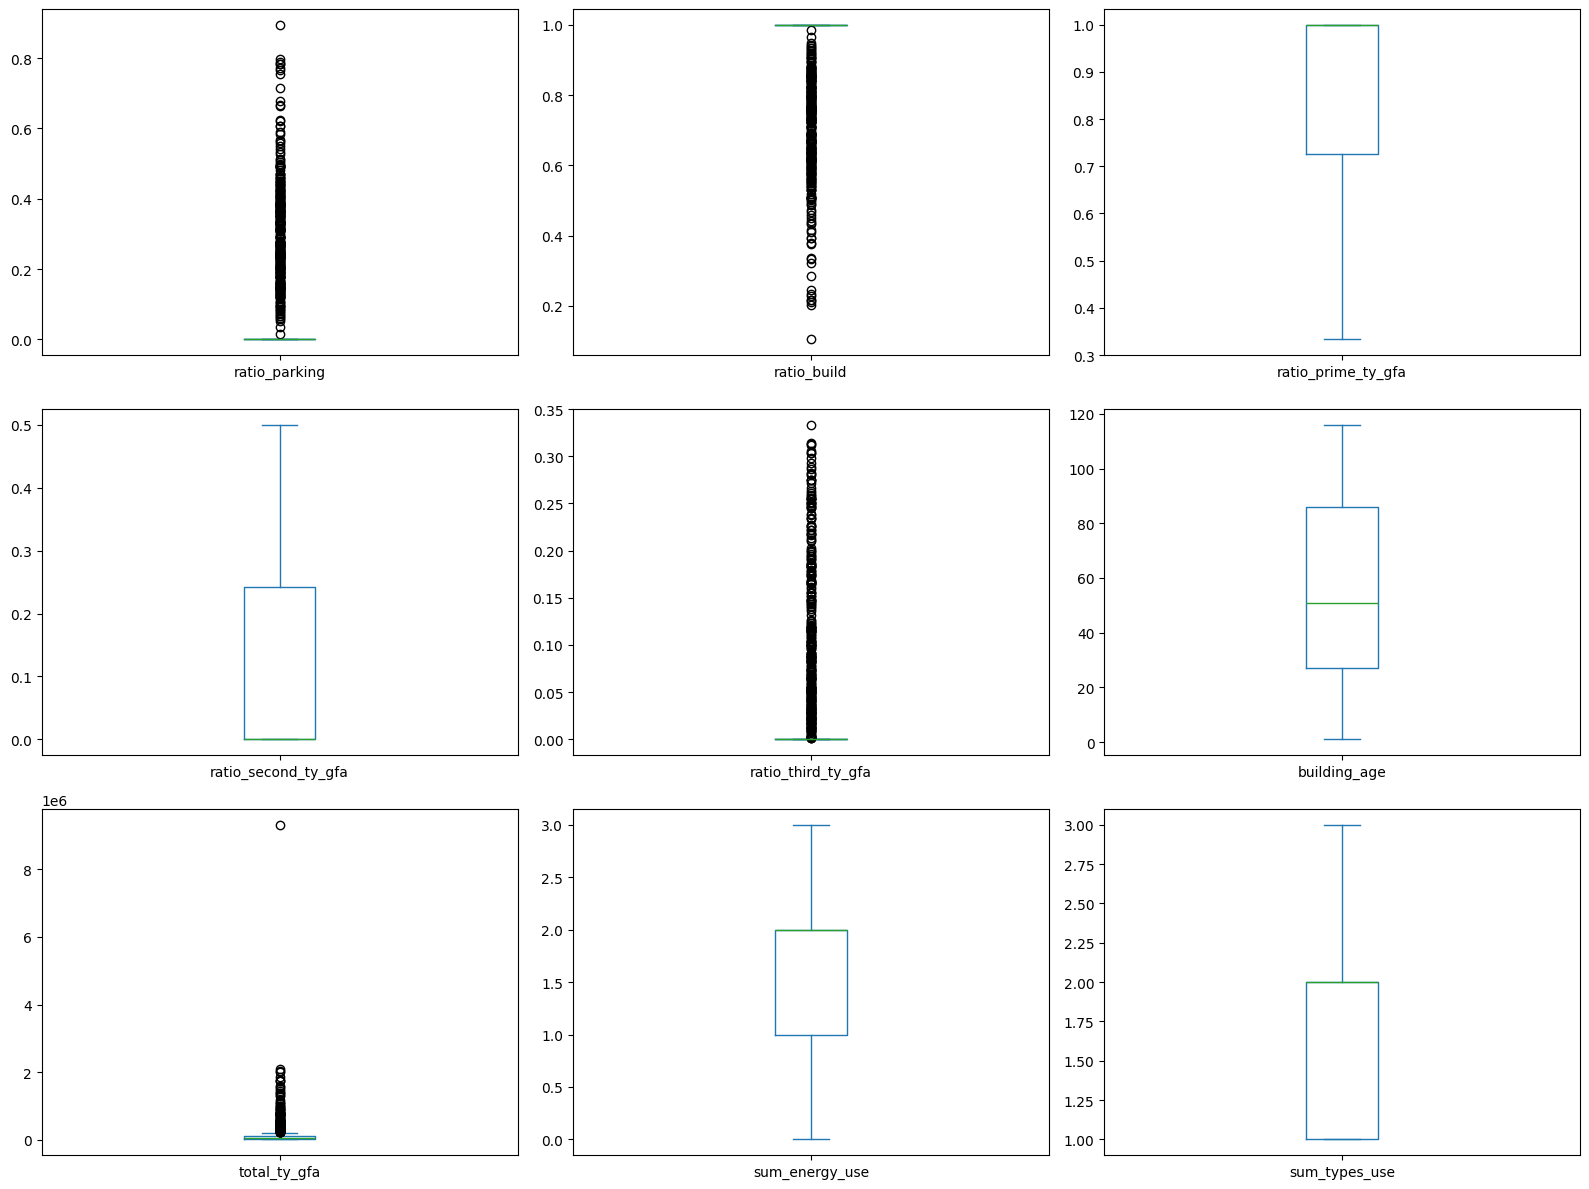

In [63]:
# boxplots
df_s2[ratio_feats + other_feats].plot(kind = 'box', subplots = True, layout = (3, 3), figsize = (16, 12))
plt.tight_layout()
plt.show()

In [64]:
# Analyse des outliers
df_s2['total_ty_gfa'].describe()
df_s2[df_s2['total_ty_gfa'] == df_s2['total_ty_gfa'].max()]

,BuildingType,PrimaryPropertyType,Neighborhood,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,...,use_gaz,use_steam,sum_energy_use,total_ty_gfa,ratio_prime_ty_gfa,ratio_second_ty_gfa,ratio_third_ty_gfa,has_second_use,has_third_use,sum_types_use
3274,Campus,University,NORTHEAST,111.0,0,9320156,0,9320156,College/University,College/University,...,0,1,2,9320156.0,1.0,0.0,0.0,0,0,1


Pour la colonne la variable total_ty_gfa on observe un otlier extreme mais qui est juste il faut donc le garder car c'est une grande université.  
Pour les colonnes ratio, l'IQR est vide donc ce qui existe est placé comme outlier, d'ou ces données mais elle reste juste.

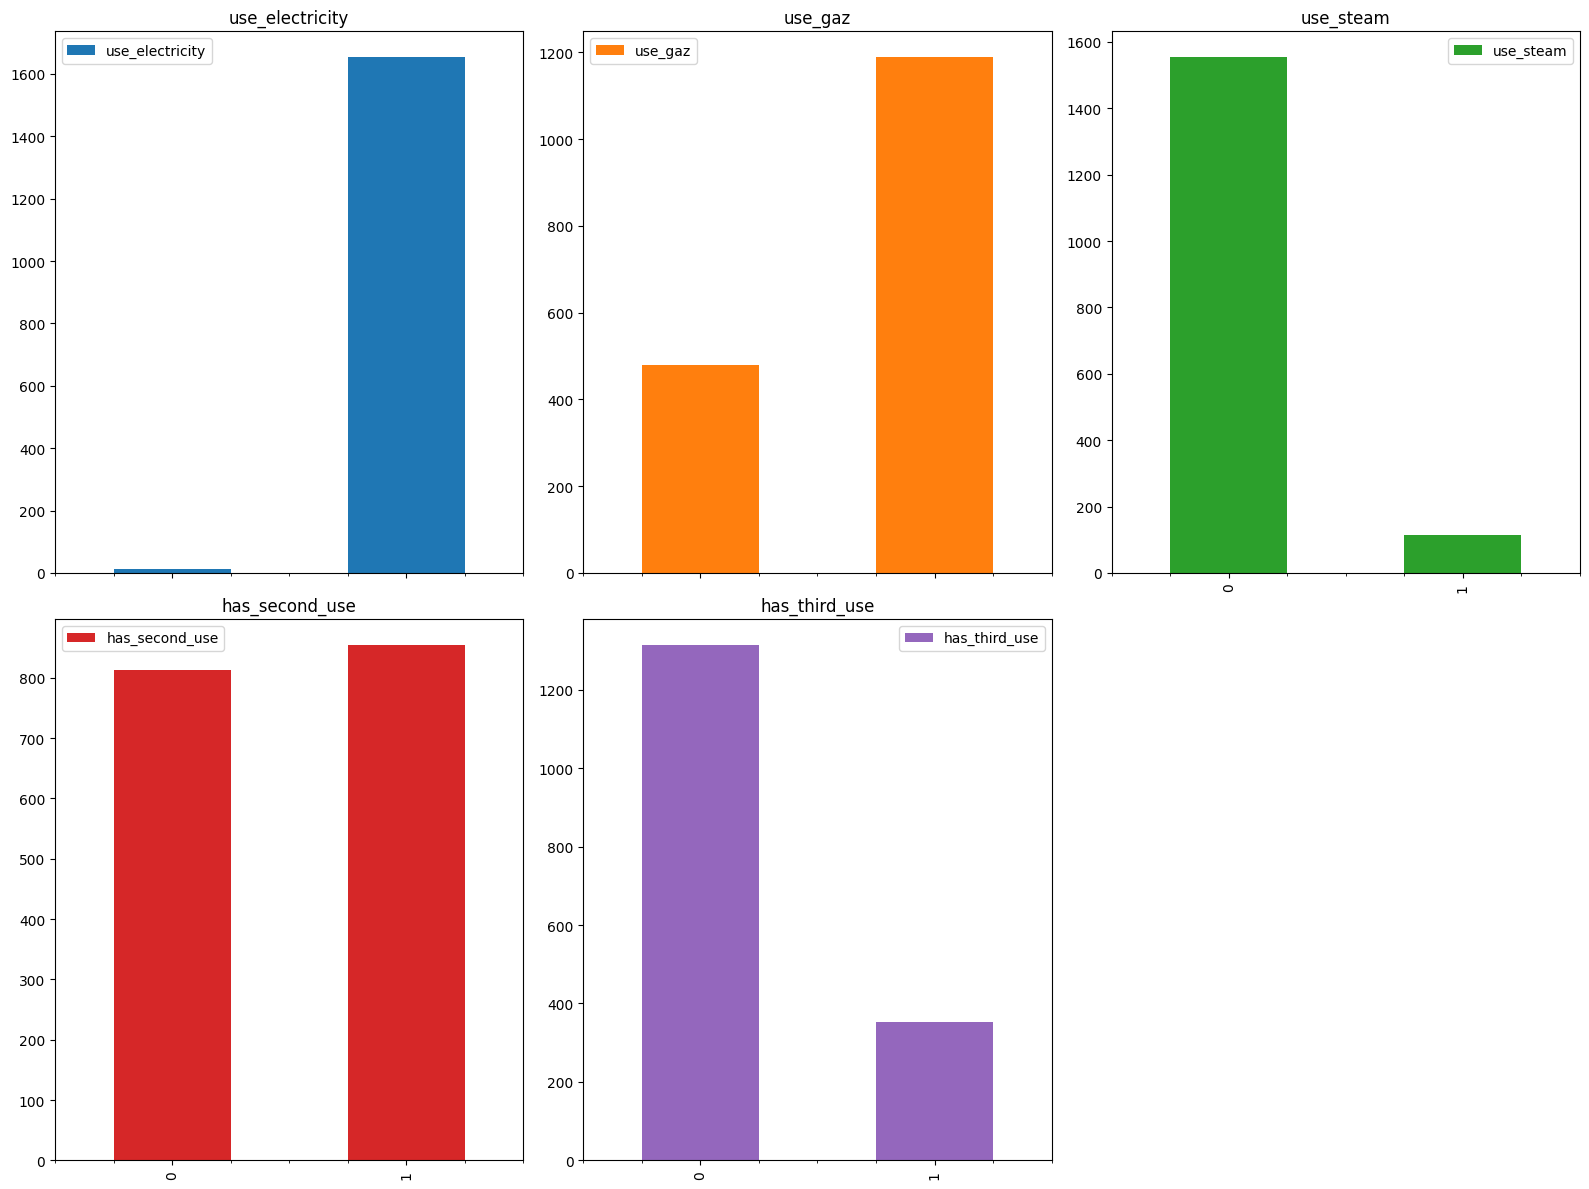

In [65]:
# barplots
df_s2[bool_feats].apply(pd.Series.value_counts).plot(kind = 'bar', subplots = True,   layout = (2,3), figsize = (16,12) )
plt.tight_layout()
plt.show()

Les barplots sont très coherents.  
La feature sur l'usage est très peu discriminante, il n'est pas utile de la garder pour la modélisation.   
Toutefois on confirmera ca avec la heatmap de correlation.

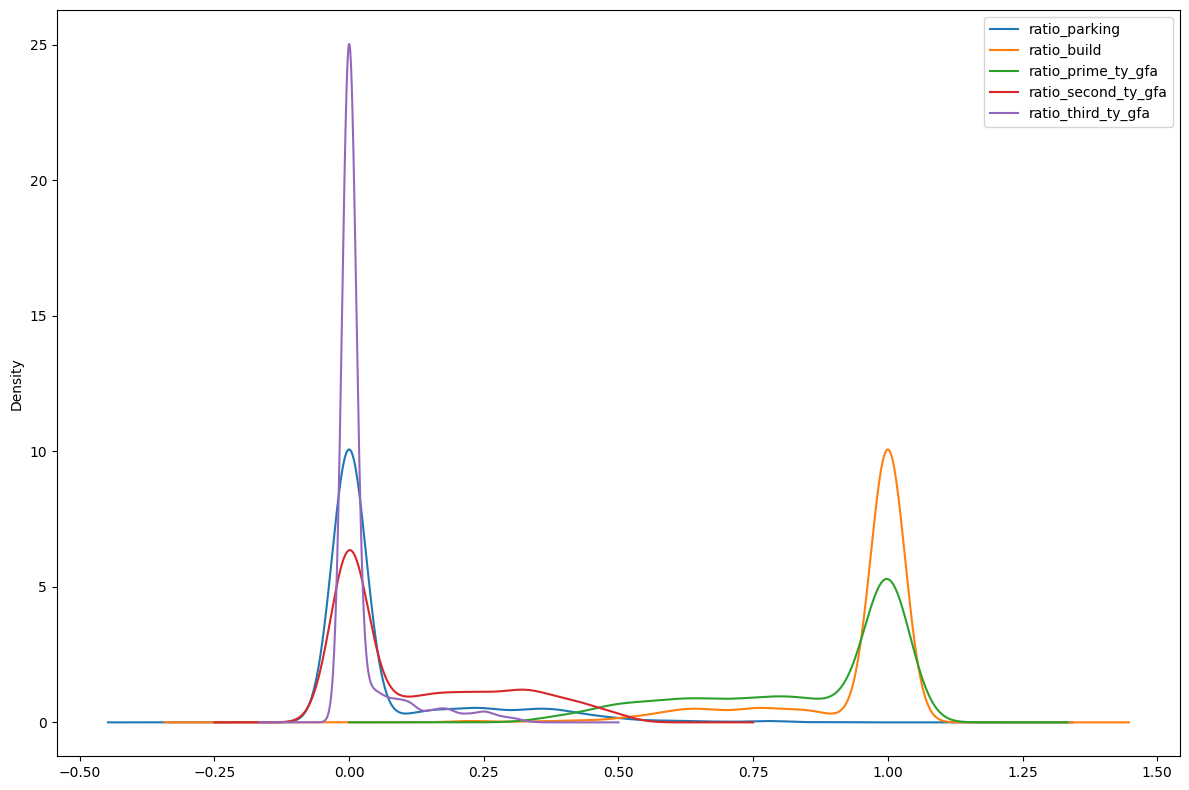

In [66]:
#Histogramme
df_s2[ratio_feats].plot(kind = 'kde', figsize = (12, 8))
plt.legend()
plt.tight_layout()
plt.show()

En conclusion :
- La majorité des bâtiments sont mono ou double usage mais pas triple usage; courbe violette (triple)élevée à 0. 
- Peu ont un troisième usage.
- La plupart n'ont pas ou très peu de parking, mais la symmétrie est troublante, cela indique qu'il ne s'agit pas vraiement de parking au sens propre mais plutôt de l'espace non - batie, car il s'oppose mecaniquement (symetriquement par le ratio partie/globale) au building...par consequent cette features c'est pas nécessaire.
- **Les ratios sont complémentaires par construction, cela se voit par l'effet miroir entre les courbes, il y a donc de la redondance dans les features.**

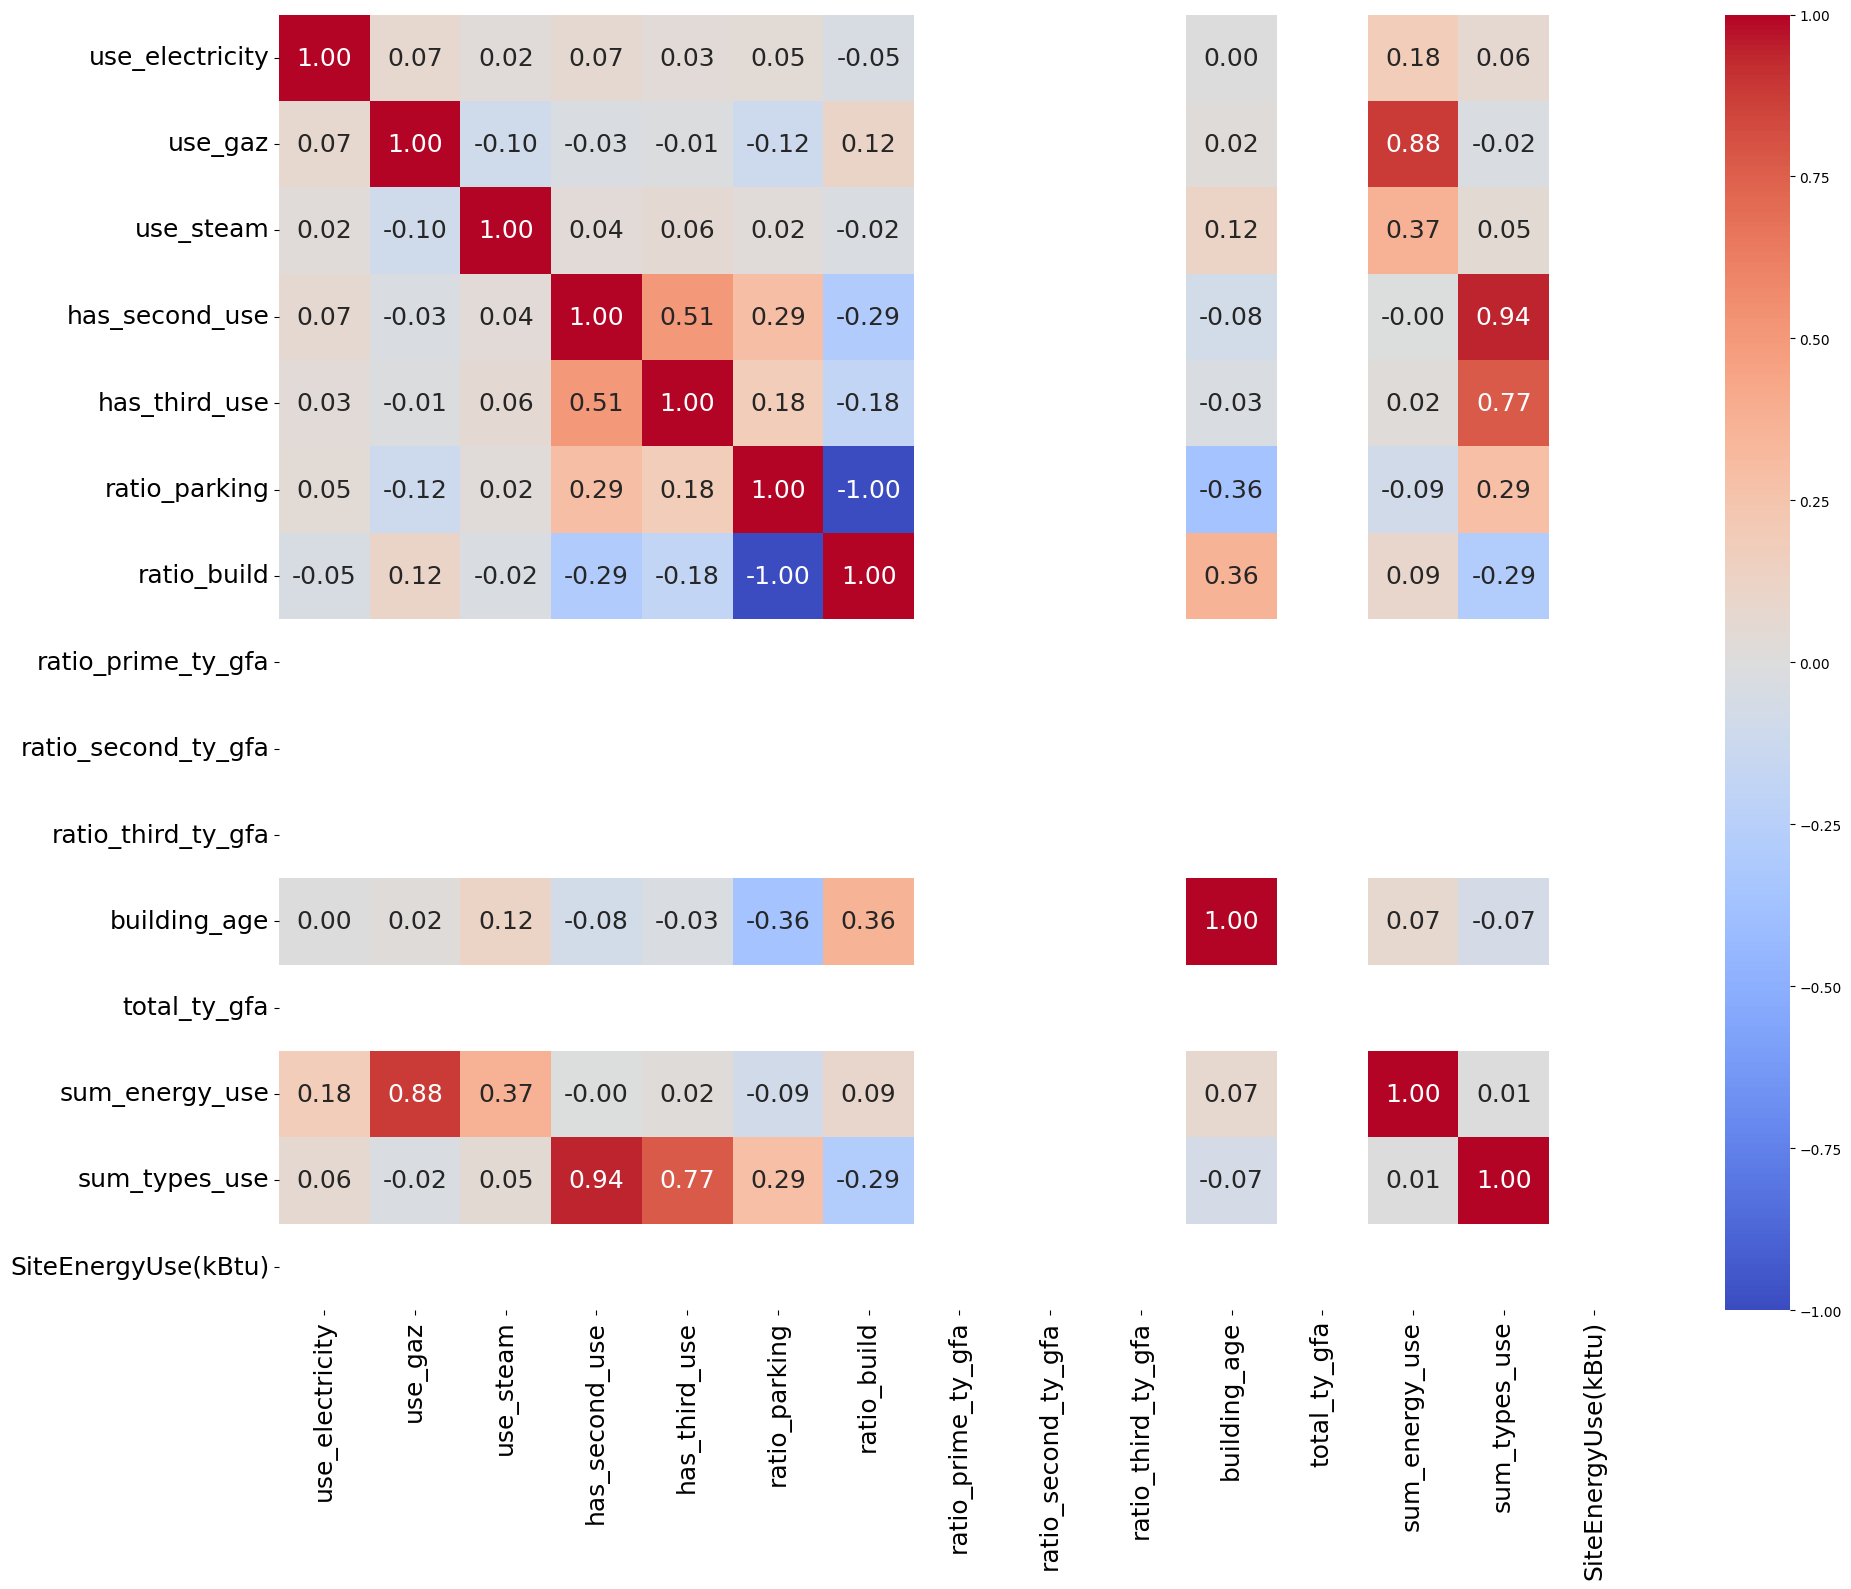

In [67]:
# heatmap de correlation des features
feat_corr = df_s2[bool_feats + ratio_feats + other_feats + ['SiteEnergyUse(kBtu)']].select_dtypes(include = 'number').columns

corr_matrix, p_matrix = spearmanr(df_s2[feat_corr])


plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=True, 
    fmt='.2f', 
    cmap= 'coolwarm', 
    annot_kws={"size": 18}, 
    xticklabels=feat_corr,  # Utilisation directe de vos colonnes
    yticklabels=feat_corr,
    mask=(p_matrix >= 100.00)
    )
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.tight_layout()
plt.show()



À partir de cette heatmap nous allons decider des features à conserver et celle à supprimer.  
À noter, il s'agit d'une heatmap 'spearman' et non 'pearson'. Spearman = présence de outliers et de binaire donc plus pertinent car moins proportionnel( correspond plus pearson).

- Les features à conserver : 
- 
  - 

In [68]:
df_s2.columns.to_list()

['BuildingType',
 'PrimaryPropertyType',
 'Neighborhood',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'SiteEnergyUse(kBtu)',
 'YearBuilt',
 'Electricity(kWh)',
 'NaturalGas(therms)',
 'SteamUse(kBtu)',
 'building_age',
 'ratio_parking',
 'ratio_build',
 'use_electricity',
 'use_gaz',
 'use_steam',
 'sum_energy_use',
 'total_ty_gfa',
 'ratio_prime_ty_gfa',
 'ratio_second_ty_gfa',
 'ratio_third_ty_gfa',
 'has_second_use',
 'has_third_use',
 'sum_types_use']

In [69]:
df_s2[feat_corr].corr( method=  'spearman').round(2).to_csv('feat_corr_cleaning.csv')